# Seminar 4

## Team members

Ana Enrech (284144) | Manel Gutierrez (286144) | Andrea Ochaita (284169)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Part I: Data preparation & analysis**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

base_path = '/content/drive/MyDrive/AAX/seminar 4/dataset/'

train = pd.read_csv(base_path + 'train_data.csv')
test = pd.read_csv(base_path + 'test_data.csv')

print("Train shape:", train.shape)
print(train.head())

print("\nTest shape:", test.shape)
print(test.head())

Train shape: (33600, 7)
   LocationNumber   RSSI  TxLinkSpeed  RxLinkSpeed  MainAPConnect  \
0               2 -72.32       163.11       118.36              1   
1              32 -73.18       238.45       212.83              1   
2              20 -40.67       865.44       863.39              1   
3              10 -60.66       473.89       396.92              1   
4              29 -67.96       479.74       355.99              1   

   TxThroughput  AvgPingLatency  
0         13.51           51.79  
1          3.35           68.80  
2         17.62           50.79  
3         14.30           64.15  
4          4.81           73.81  

Test shape: (8400, 7)
   LocationNumber   RSSI  TxLinkSpeed  RxLinkSpeed  MainAPConnect  \
0              16 -53.19       787.51       653.48              1   
1              24 -62.79       657.90       592.37              1   
2              34 -71.16       259.18       178.29              0   
3              28 -63.99       467.56       375.04        

The training dataset contains 33,600 samples and 7 columns. The variables are LocationNumber, RSSI, TxLinkSpeed, RxLinkSpeed, MainAPConnect, TxThroughput and AvgPingLatency.

The first five variables are used as input features, and the latest TxThroughput and AvgPingLatency are the performance metrics that we want to predict.

In [ ]:
print(train.columns)
print(train.info())
print(train.describe())

Index(['LocationNumber', 'RSSI', 'TxLinkSpeed', 'RxLinkSpeed', 'MainAPConnect',
       'TxThroughput', 'AvgPingLatency'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33600 entries, 0 to 33599
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   LocationNumber  33600 non-null  int64  
 1   RSSI            33600 non-null  float64
 2   TxLinkSpeed     33600 non-null  float64
 3   RxLinkSpeed     33600 non-null  float64
 4   MainAPConnect   33600 non-null  int64  
 5   TxThroughput    33600 non-null  float64
 6   AvgPingLatency  33600 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 1.8 MB
None
       LocationNumber          RSSI   TxLinkSpeed   RxLinkSpeed  \
count    33600.000000  33600.000000  33600.000000  33600.000000   
mean        18.151161    -62.364212    491.264874    460.954107   
std         10.338002      9.442463    240.868700    251.600115   
min          1.00000

The descriptive statistics show the range, mean, standard deviation and quartiles of each variable.

LocationNumber ranges from 1 to 36, the measurements were collected from different zones. The average location number is around 18,15.

RSSI has an average value of -62.36 dBm, with values ranging from -79.04 dBm to -37.02 dBm. Since RSSI values are negative, values closer to 0 indicate a stronger signal, while more negative values indicate a weaker signal.

TxLinkSpeed has an average value of 491.26, while RxLinkSpeed has an average value of 460.95. Both variables have a high standard deviation, which means that the link speed changes a lot depending on the measurement.

MainAPConnect has a mean of 0.914. Since this variable is binary, this means that most samples correspond to devices connected to the main AP rather than to an extender.

TxThroughput has an average value of 12.99 and ranges from 0.78 to 19.16. The median is 14.79, which is higher than the mean, suggesting that some low throughput values reduce the average.

AvgPingLatency has an average value of 54.77 ms and ranges from 39.30 ms to 96.55 ms. Most latency values are around 50 ms, but there are some higher latency values.

To continue, we plot the relevant figures to visualize how data is distributed.

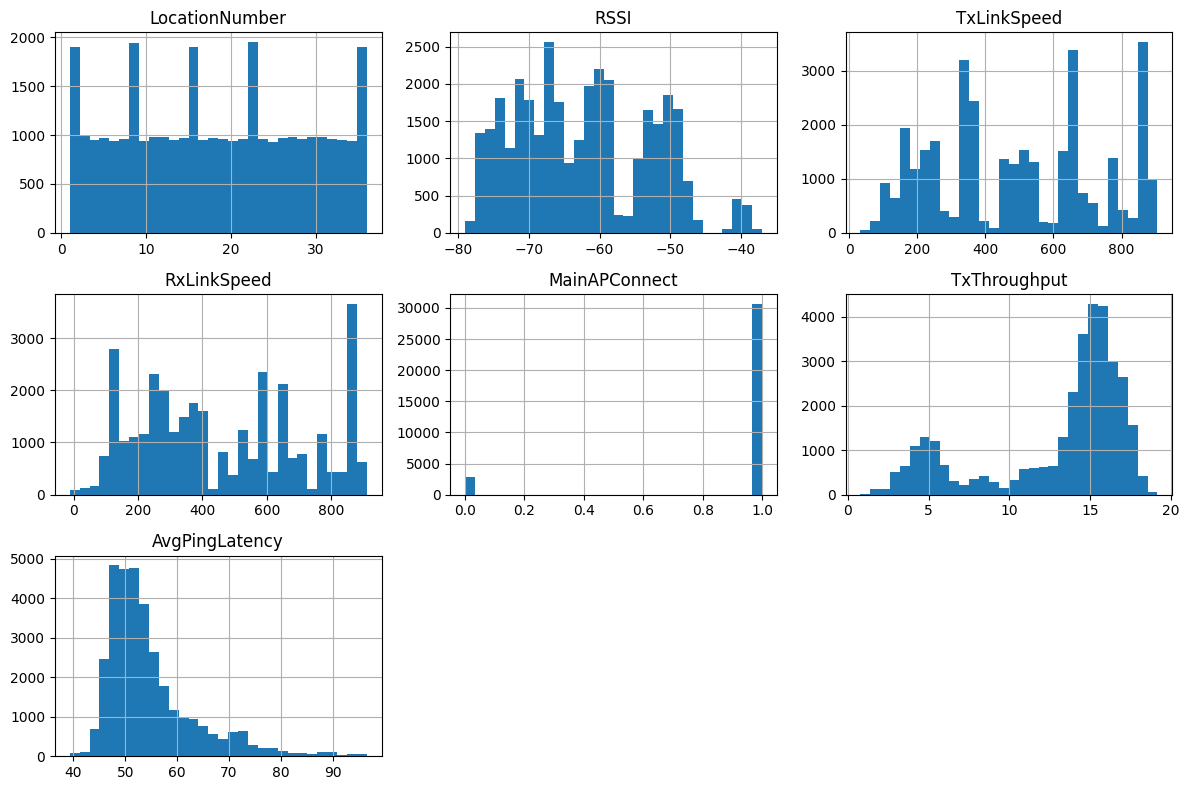

In [ ]:
train.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

RSSI values are mostly concentrated between approximately -75 dBm and -50 dBm. TxLinkSpeed and RxLinkSpeed have a wide range of values, which indicates that the wireless link quality changes significantly between samples.

MainAPConnect is clearly imbalanced, because most values are 1. This means that most devices are connected to the main AP.

TxThroughput is mostly concentrated in medium-high values, although there are also some low throughput samples. AvgPingLatency is mainly concentrated around 45-60 ms, but it also has a tail with higher latency values.

To study the relationship between the features and the performance metrics, we computed the correlation matrix. Correlation values close to 1 indicate a positive linear relationship, values close to -1 indicate a negative linear relationship, and values close to 0 indicate a weak linear relationship.

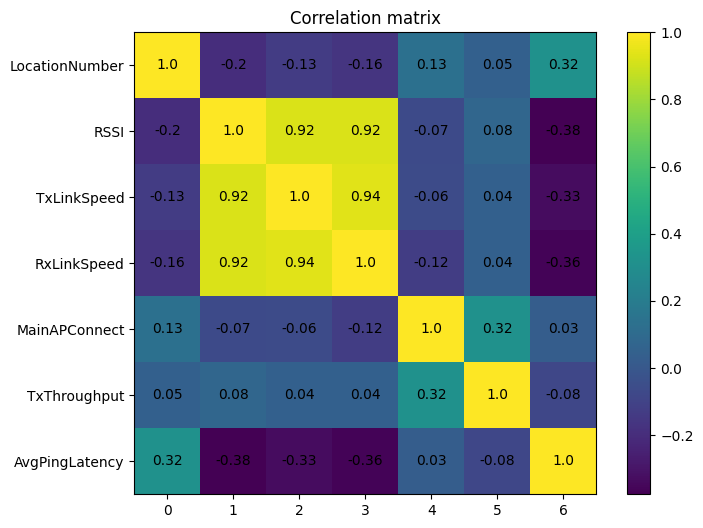

In [ ]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar()

plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha='center', va='center')

plt.title("Correlation matrix")
plt.show()

For TxThroughput, the feature with the highest correlation is MainAPConnect, with a correlation of 0.321. This suggests that being connected to the main AP is related to higher throughput. The rest of the features have very low correlation with TxThroughput: RSSI, LocationNumber, TxLinkSpeed and RxLinkSpeed are all close to 0. This means that throughput is not strongly explained by a simple linear relationship with these individual variables.

AvgPingLatency shows clearer correlations. RSSI has a negative correlation of -0.376 with latency. This means that when the signal is stronger, the latency tends to decrease. TxLinkSpeed and RxLinkSpeed also have negative correlations with latency, around -0.331 and -0.362. Therefore, higher link speeds are related to lower delay.

LocationNumber has a positive correlation of 0.323 with AvgPingLatency, which suggests that the position of the device has an important effect on latency. Finally, the correlation between TxThroughput and AvgPingLatency is slightly negative, around -0.081, meaning that higher throughput is only weakly associated with lower latency.

In [ ]:
print("Correlation with TxThroughput:")
print(corr['TxThroughput'].sort_values(ascending=False))

print("\nCorrelation with AvgPingLatency:")
print(corr['AvgPingLatency'].sort_values(ascending=False))

Correlation with TxThroughput:
TxThroughput      1.000000
MainAPConnect     0.321010
RSSI              0.076853
LocationNumber    0.046687
TxLinkSpeed       0.044451
RxLinkSpeed       0.044280
AvgPingLatency   -0.080901
Name: TxThroughput, dtype: float64

Correlation with AvgPingLatency:
AvgPingLatency    1.000000
LocationNumber    0.322541
MainAPConnect     0.028982
TxThroughput     -0.080901
TxLinkSpeed      -0.331170
RxLinkSpeed      -0.361945
RSSI             -0.375971
Name: AvgPingLatency, dtype: float64


The main performance metrics are TxThroughput and AvgPingLatency. Throughput seems to be more related to whether the device is connected to the main AP, while latency is more related to RSSI and link speed values.

# **Part II: FNN-based performance predictor**

## 1. Feature selection

We selected the following input features: LocationNumber, RSSI, TxLinkSpeed, RxLinkSpeed and MainAPConnect.
The output labels are TxThroughput and AvgPingLatency.

In [ ]:
features = ['LocationNumber', 'RSSI', 'TxLinkSpeed', 'RxLinkSpeed', 'MainAPConnect']
labels = ['TxThroughput', 'AvgPingLatency']

X_train = train[features]
y_train = train[labels]

X_test = test[features]
y_test = test[labels]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (33600, 5)
y_train shape: (33600, 2)
X_test shape: (8400, 5)
y_test shape: (8400, 2)


## 2. Data Preparation

LocationNumber represents the zone where the data was collected. Since this value identifies a location, we encode it using one-hot encoding. This creates one binary column for each location and avoids treating the location number as a continuous physical value.

In [ ]:
features = ['LocationNumber', 'RSSI', 'TxLinkSpeed', 'RxLinkSpeed', 'MainAPConnect']
X_train = train[features].copy()
X_test = test[features].copy()

X_train = pd.get_dummies(X_train, columns=['LocationNumber'])
X_test = pd.get_dummies(X_test, columns=['LocationNumber'])

#ens assegurem que test tingui les mateixes columnes que train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

After encoding, we normalize the input and output data. This is important because the variables have different scales, so normalization makes training easier for the neural network.

In [ ]:
X_mean = X_train.mean()
X_std = X_train.std().replace(0, 1)

y_mean = y_train.mean()
y_std = y_train.std().replace(0, 1)

X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

y_train_norm = (y_train - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

print(X_train_norm.head())
print(y_train_norm.head())

       RSSI  TxLinkSpeed  RxLinkSpeed  MainAPConnect  LocationNumber_1  \
0 -1.054363    -1.362381    -1.361661       0.306821         -0.169927   
1 -1.145441    -1.049596    -0.986184       0.306821         -0.169927   
2  2.297516     1.553440     1.599506       0.306821         -0.169927   
3  0.180484    -0.072134    -0.254507       0.306821         -0.169927   
4 -0.592620    -0.047847    -0.417186       0.306821         -0.169927   

   LocationNumber_2  LocationNumber_3  LocationNumber_4  LocationNumber_5  \
0          5.846557         -0.174416         -0.170944         -0.172322   
1         -0.171036         -0.174416         -0.170944         -0.172322   
2         -0.171036         -0.174416         -0.170944         -0.172322   
3         -0.171036         -0.174416         -0.170944         -0.172322   
4         -0.171036         -0.174416         -0.170944         -0.172322   

   LocationNumber_6  ...  LocationNumber_26  LocationNumber_27  \
0         -0.169741  ...  

## 3. FNN architecture design

After applying one-hot encoding to LocationNumber, the input size increased from 5 original features to 39 processed features.

To handle this expanded feature space, the optimized network utilizes three hidden layers containing 128, 64, and 32 neurons, respectively.
We use more neurons in the first hidden layer because it receives all the processed input information, including the encoded locations.The subsequent hidden layers progressively scale down in size, forcing the model to compress and synthesize the learned features into compact, highly meaningful representations.

ReLU activation is used in the hidden layers because it allows the model to learn non-linear relationships between variables and performance. Additionally, we introduced Dropout layers with a rate of 0.1 after the first two hidden layers, this introduces regularization during training, which improves generalization and prevents the model from overfitting as it runs for more epochs.

Finally, the output layer consists of 2 neurons, which directly predict the target continuous metrics: TxThroughput and AvgPingLatency.

In [ ]:
# Model capacity and prepare for regularization
input_size = X_train_norm.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_size,)),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.1),  # Protects against overfitting

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.1),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Output layer for TxThroughput and AvgPingLatency
])

# Define optimizer configuration
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Define callbacks for dynamic training adjustments
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,             # Stop if val_loss doesn't improve for 15 epochs
        restore_best_weights=True # Keep the weights from the lowest val_loss epoch
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,              # Cut the learning rate in half
        patience=6,              # If val_loss stalls for 6 epochs
        min_lr=1e-6
    )
]

## 4. Train the FNN

The model is trained using the training dataset. We used 150 epochs and a batch size of 64.

The validation data is useful to check if the model is learning correctly or if it starts overfitting.

In [ ]:
history = model.fit(
    X_train_norm, y_train_norm,
    epochs=150,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6566 - mae: 0.6064 - val_loss: 0.6247 - val_mae: 0.5966 - learning_rate: 0.0010
Epoch 2/150
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6188 - mae: 0.5869 - val_loss: 0.6199 - val_mae: 0.5830 - learning_rate: 0.0010
Epoch 3/150
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6140 - mae: 0.5828 - val_loss: 0.6129 - val_mae: 0.5893 - learning_rate: 0.0010
Epoch 4/150
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6081 - mae: 0.5808 - val_loss: 0.6099 - val_mae: 0.5812 - learning_rate: 0.0010
Epoch 5/150
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6038 - mae: 0.5772 - val_loss: 0.6050 - val_mae: 0.5844 - learning_rate: 0.0010
Epoch 6/150
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5960 - mae: 0.5746 - val_loss: 0.5993 - val_mae: 0.5809 - learning_rate: 0.0010
Epoch 7/150
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5918 - mae: 0.5713 - val_loss: 0.5929 - val_mae: 0.5718 - learning_rate: 0.0010

We plot the training loss and validation loss for each epoch. If both losses decrease, the model is learning.

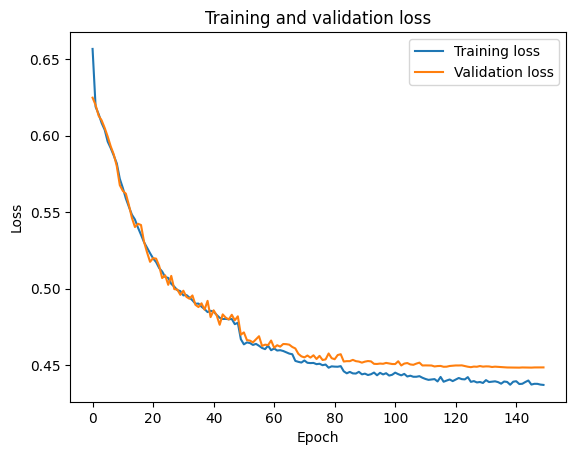

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

The loss plot confirms that the neural network is learning. At the beginning, the loss decreases quickly. After, the decrease becomes slower, so the model is still improving.

## 5. Evaluate the FNN

In [ ]:
pred_norm = model.predict(X_test_norm)

pred = pred_norm * y_std.values + y_mean.values
pred = pd.DataFrame(pred, columns=labels)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


We use MAE and RMSE. MAE measures the average absolute error between the real and predicted values. RMSE also measures the prediction error, but it penalizes large errors more strongly.

In [ ]:
for label in labels:
    error = y_test[label] - pred[label]

    mae = abs(error).mean()
    rmse = ((error ** 2).mean()) ** 0.5

    print(label)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print()

TxThroughput
MAE: 2.43996159063925
RMSE: 3.3814049604199354

AvgPingLatency
MAE: 3.359300250301448
RMSE: 4.84444413640623



For TxThroughput, the model has MAE of 2.45 and a RMSE of 3.39. This means that, the throughput prediction is wrong by around 2.45 throughput units. The RMSE is higher than the MAE, which indicates that some samples have larger prediction errors.

For AvgPingLatency, the model obtains a MAE of 3.36 ms and a RMSE of 4.86 ms. Since the average latency in the training set was around 54.77 ms, an average error of 3.36 ms is relatively moderate. The model seems to predict latency better than throughput.

This difference makes sense considering the correlation analysis from Part I. AvgPingLatency has clearer relationships with RSSI, TxLinkSpeed and RxLinkSpeed, while TxThroughput has less correlations.

We compare the real values with the predicted values. If the model performs well, the points should be close to the diagonal line, meaning that the predicted values are close to the real ones.

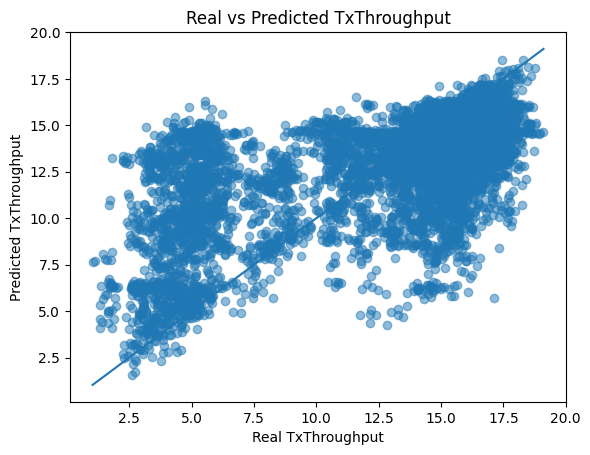

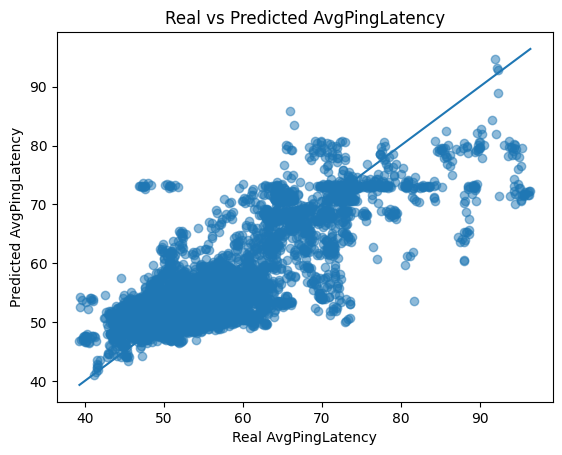

In [ ]:
for label in labels:
    plt.figure()
    plt.scatter(y_test[label], pred[label], alpha=0.5)

    min_value = min(y_test[label].min(), pred[label].min())
    max_value = max(y_test[label].max(), pred[label].max())
    plt.plot([min_value, max_value], [min_value, max_value])

    plt.xlabel("Real " + label)
    plt.ylabel("Predicted " + label)
    plt.title("Real vs Predicted " + label)
    plt.show()

For TxThroughput, the  plot shows that the model captures the general range of the throughput values, but it does not perfectly follow the diagonal line. Many predictions are concentrated around medium-high throughput values. This means that the model tends to predict values close to the average throughput.
This also agrees with the correlation analysis, TxThroughput did not show a strong linear correlation with most input features.

For AvgPingLatency, the plot shows a clearer relationship between the real and predicted values. Many points are closer to the diagonal line. This indicates that the model is able to capture the main latency behavior better than the throughput behavior.
However, the model still has some limitations. High latency values are often underestimated.

In conclusion, the latency prediction is better than the throughput prediction, which is consistent with the lower relative error and with the stronger correlations observed in the data analysis.

In [ ]:
results = y_test.copy()

results['Predicted_TxThroughput'] = pred['TxThroughput']
results['Predicted_AvgPingLatency'] = pred['AvgPingLatency']

print(results.head(10))

   TxThroughput  AvgPingLatency  Predicted_TxThroughput  \
0         15.94           56.30                9.457456   
1         17.31           49.78               15.243135   
2          2.89           55.83                4.720440   
3         17.01           85.71               13.562292   
4         14.05           59.40               13.591597   
5         14.49           51.78               13.239511   
6         13.51           79.20               14.315779   
7         15.69           53.95                8.964823   
8          5.54           45.97               13.369728   
9          6.32           48.78               13.943048   

   Predicted_AvgPingLatency  
0                 52.413240  
1                 50.742469  
2                 54.827441  
3                 78.066397  
4                 51.999001  
5                 50.228270  
6                 74.781952  
7                 52.311585  
8                 50.189226  
9                 50.415290  


In order to be more accurate, we plot this table to ensure our conclusion about the model.

For TxThroughput, the model predicts reasonable values for some samples, especially when the real throughput is around medium-high values. In sample 4, the real TxThroughput is 14.05 and the predicted value is 14.28, very close. In sample 6, the real value is 13.51 and the prediction is 14.28, also a good prediction. The model has more difficulty with low throughput values. In sample 8, the real TxThroughput is 5.54 but the model predicts 12.93. In sample 9, the real value is 6.32 but the prediction is 13.98. This shows that the model tends to overestimate low throughput cases. In general, the model seems to predict values close to the average throughput.


For AvgPingLatency, the predictions are generally better. In sample 2, the real latency is 55.83 ms and the predicted latency is 56.06 ms. But, in sample 3, the real latency is 85.71 ms and the prediction is 78.40 ms, so the model detects that latency is high but underestimates the extreme value.

Overall, this table confirms what we observed with the MAE, RMSE and the real vs predicted plots. The model predicts latency more accurately than throughput.